# 02 - Comparing four models

1. Logistic Regression
2. Decision Tree
3. K-Nearest Neighbours (KNN)
4. Random Forest

## Step 1: Get the data and pipeline from src folder under the file setup.py

In [1]:
import sys, warnings
sys.path.append('..')            # so we can import from the src/ folder
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

from src.setup import prepare_everything, evaluate

X_train, X_test, y_train, y_test, preprocessing, cv = prepare_everything()

print('Training rows:', X_train.shape[0])
print('Testing rows: ', X_test.shape[0])
print('Pipeline ready (see ../src/setup.py for exactly what it does).')

Training rows: 5634
Testing rows:  1409
Pipeline ready (see ../src/setup.py for exactly what it does).


## Step 2: Model 1 - Logistic Regression


In [2]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
row_log_reg = evaluate(log_reg, 'Logistic Regression', X_train, y_train, preprocessing, cv)
row_log_reg

{'model': 'Logistic Regression',
 'accuracy (mean)': np.float64(0.803),
 'accuracy (spread)': np.float64(0.012),
 'f1 (mean)': np.float64(0.593),
 'f1 (spread)': np.float64(0.03),
 'roc_auc (mean)': np.float64(0.846),
 'roc_auc (spread)': np.float64(0.013)}

## Step 3: Model 2 - Decision Tree


In [3]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=6, random_state=42)
row_tree = evaluate(tree, 'Decision Tree', X_train, y_train, preprocessing, cv)
row_tree

{'model': 'Decision Tree',
 'accuracy (mean)': np.float64(0.789),
 'accuracy (spread)': np.float64(0.012),
 'f1 (mean)': np.float64(0.564),
 'f1 (spread)': np.float64(0.03),
 'roc_auc (mean)': np.float64(0.824),
 'roc_auc (spread)': np.float64(0.016)}

## Step 4: Model 3 - K-Nearest Neighbours (KNN)


In [4]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=15)
row_knn = evaluate(knn, 'K-Nearest Neighbours', X_train, y_train, preprocessing, cv)
row_knn

{'model': 'K-Nearest Neighbours',
 'accuracy (mean)': np.float64(0.786),
 'accuracy (spread)': np.float64(0.008),
 'f1 (mean)': np.float64(0.584),
 'f1 (spread)': np.float64(0.014),
 'roc_auc (mean)': np.float64(0.824),
 'roc_auc (spread)': np.float64(0.009)}

## Step 5: Model 4 - Random Forest


In [5]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
row_forest = evaluate(forest, 'Random Forest', X_train, y_train, preprocessing, cv)
row_forest

{'model': 'Random Forest',
 'accuracy (mean)': np.float64(0.803),
 'accuracy (spread)': np.float64(0.011),
 'f1 (mean)': np.float64(0.571),
 'f1 (spread)': np.float64(0.02),
 'roc_auc (mean)': np.float64(0.846),
 'roc_auc (spread)': np.float64(0.01)}

## Step 6: Compare all four models side by side

In [6]:
comparison = pd.DataFrame([row_log_reg, row_tree, row_knn, row_forest])
comparison = comparison.set_index('model')
comparison = comparison.sort_values('f1 (mean)', ascending=False)
comparison

,accuracy (mean),accuracy (spread),f1 (mean),f1 (spread),roc_auc (mean),roc_auc (spread)
model,,,,,,
Logistic Regression,0.803,0.012,0.593,0.030,0.846,0.013
K-Nearest Neighbours,0.786,0.008,0.584,0.014,0.824,0.009
Random Forest,0.803,0.011,0.571,0.020,0.846,0.010
Decision Tree,0.789,0.012,0.564,0.030,0.824,0.016


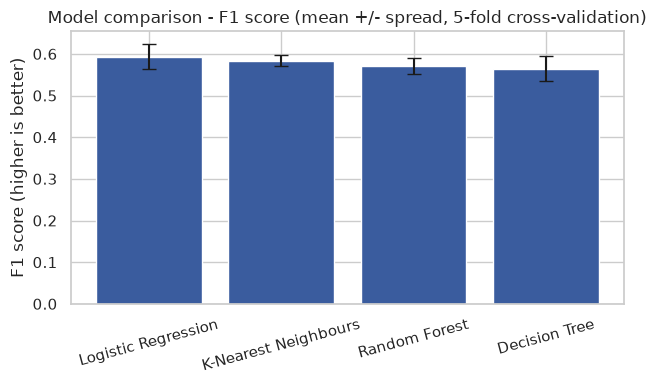

In [8]:
plt.figure(figsize=(6.5, 4))
plt.bar(
    comparison.index,
    comparison['f1 (mean)'],
    yerr=comparison['f1 (spread)'],
    capsize=5,
    color='#3a5c9e',
)
plt.ylabel('F1 score (higher is better)')
plt.title('Model comparison - F1 score (mean +/- spread, 5-fold cross-validation)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../figures/model_comparison_f1.png', dpi=150)
plt.show()

Logistic Regression has the highest average F1 score of 0.593, followed by K-Nearest Neighbours at 0.585, Random Forest at 0.571, and Decision Tree at 0.564. This means Logistic Regression performed best at identifying customers who are likely to churn while balancing precision and recall.

Logistic Regression has an F1 spread of 0.030, which is the same as the Decision Tree and higher than the spreads of K-Nearest Neighbours (0.014) and Random Forest (0.020). This means Logistic Regression achieved the highest average F1 score, but its performance varied more across the folds than those of K-Nearest Neighbours and Random Forest. K-Nearest Neighbours was the most consistent model based on its F1 spread.

We would choose Logistic Regression for further tuning because it achieved the highest average F1 score of 0.593 and tied with Random Forest for the highest average ROC-AUC of 0.846. Although its F1 score varied more across the folds, tuning its parameters may improve its performance and consistency. I would also consider Random Forest as a second model because it had the same average ROC-AUC and a slightly smaller F1 spread.
